# Single-LoS GLRT AoA Simu



In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)

In [2]:
def steering_vector(theta_deg, M, d_over_lambda=0.5):
    """Normalized ULA steering vector.

    Args:
        theta_deg: AoA in degrees (scalar or vector).
        M: number of receive antennas (array elements).
        d_over_lambda: antenna spacing normalized by wavelength.
    """
    theta_deg_arr = np.atleast_1d(theta_deg).astype(float)
    theta_rad = np.deg2rad(theta_deg_arr)
    m = np.arange(M, dtype=float)
    phase = 2.0 * np.pi * d_over_lambda * np.outer(m, np.sin(theta_rad))
    A = np.exp(1j * phase) / np.sqrt(M)
    if np.ndim(theta_deg) == 0:
        return A[:, 0]
    return A


def square_qam_symbols(T, order=16, rng=None):
    """Generate unit-power square QAM symbols."""
    if T < 1:
        raise ValueError('T must be >= 1 (number of snapshots).')

    if rng is None:
        rng = np.random.default_rng()

    m = int(np.sqrt(order))
    if m * m != order:
        raise ValueError('order must be a perfect square, e.g. 4, 16, 64.')

    levels = np.arange(-(m - 1), m, 2)
    i = rng.choice(levels, size=T)
    q = rng.choice(levels, size=T)
    s = i + 1j * q
    s = s / np.sqrt(np.mean(np.abs(s) ** 2))
    return s


def simulate_h1(theta_deg, snr_db, M, T, sigma2=1.0, qam_order=16, d_over_lambda=0.5, rng=None):
    """Simulate H1: Y = u b^T + W."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    if rng is None:
        rng = np.random.default_rng()

    u_true = steering_vector(theta_deg, M, d_over_lambda)
    s = square_qam_symbols(T, order=qam_order, rng=rng)

    # SNR definition: E[||u g s||^2] / E[||w||^2] = |g|^2 / (M * sigma2).
    snr_lin = 10.0 ** (snr_db / 10.0)
    g_mag = np.sqrt(snr_lin * M * sigma2)
    g = g_mag * np.exp(1j * rng.uniform(0.0, 2.0 * np.pi))

    b = g * s
    noise = np.sqrt(sigma2 / 2.0) * (
        rng.standard_normal((M, T)) + 1j * rng.standard_normal((M, T))
    )
    Y = np.outer(u_true, b) + noise
    return Y, u_true, b, g


def simulate_h0(M, T, sigma2=1.0, rng=None):
    """Simulate H0: Y = W."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    if rng is None:
        rng = np.random.default_rng()

    return np.sqrt(sigma2 / 2.0) * (
        rng.standard_normal((M, T)) + 1j * rng.standard_normal((M, T))
    )


def analyze_snapshot(Y, angle_grid_deg, d_over_lambda=0.5):
    """Compute dominant eigenvector, AoA estimate, and GLRT statistic."""
    M, T = Y.shape
    if M < 1 or T < 1:
        raise ValueError('Y must have shape (M, T) with M,T >= 1.')

    R = (Y @ Y.conj().T) / T
    eigvals, eigvecs = np.linalg.eigh(R)

    lambda_max = float(np.real(eigvals[-1]))
    tr_R = float(np.real(np.trace(R)))
    if tr_R <= 0.0:
        raise ValueError('Trace(R) must be > 0. Check input and sigma2.')

    # Numerical guard: for T=1 and/or high SNR, xi can be extremely close to 1.
    # Clip to avoid log(0) or log of a negative value due to floating-point error.
    xi_raw = lambda_max / tr_R
    eps = 1e-12
    xi = float(np.clip(xi_raw, 0.0, 1.0 - eps))
    log_glrt = float(M * T * (-np.log1p(-xi)))

    u_hat = eigvecs[:, -1]
    A = steering_vector(angle_grid_deg, M, d_over_lambda)
    spectrum = np.abs(A.conj().T @ u_hat) ** 2
    theta_hat = float(angle_grid_deg[np.argmax(spectrum)])

    return {
        'R': R,
        'u_hat': u_hat,
        'theta_hat': theta_hat,
        'spectrum': spectrum,
        'lambda_max': lambda_max,
        'trace_R': tr_R,
        'xi_raw': float(xi_raw),
        'xi': xi,
        'log_glrt': log_glrt,
    }


def calibrate_xi_threshold(M, T, pfa, n_trials, sigma2=1.0, seed=1):
    """Monte-Carlo threshold calibration for target false-alarm rate."""
    if M < 1 or T < 1:
        raise ValueError('M and T must both be >= 1.')

    rng = np.random.default_rng(seed)
    xi_h0 = np.empty(n_trials)
    eps = 1e-12

    for k in range(n_trials):
        Y0 = simulate_h0(M=M, T=T, sigma2=sigma2, rng=rng)
        M0, T0 = Y0.shape
        R0 = (Y0 @ Y0.conj().T) / T0
        eigvals0 = np.linalg.eigvalsh(R0)
        xi_raw = float(np.real(eigvals0[-1] / np.trace(R0)))
        xi_h0[k] = float(np.clip(xi_raw, 0.0, 1.0 - eps))

    xi_threshold = float(np.quantile(xi_h0, 1.0 - pfa))
    xi_threshold = float(np.clip(xi_threshold, 0.0, 1.0 - eps))
    psi_threshold = float(M * T * (-np.log1p(-xi_threshold)))
    return xi_threshold, psi_threshold, xi_h0


In [3]:
# Baseline setup
# M: number of receive antennas
M = 16
# T: number of snapshots (time samples)
T = 16
# sigma2: noise variance per receive dimension
sigma2 = 1.0
# constellation order for s(t), 4/16/64
qam_order = 16
d_over_lambda = 0.5
# grid for AoA search in Eq. theta_hat = argmax |a(theta)^H u_hat|^2
angle_grid_deg = np.linspace(-90.0, 90.0, 1441)
theta_true_deg = 10.0
snr_db_single = 5.0
rng_single = np.random.default_rng(2026)

# For this xi-GLRT (unknown sigma2), T=1 is degenerate: xi = lambda_max/trace ~= 1 under both H0/H1.
# So AoA estimation still works, but GLRT threshold/Pfa/Pd evaluation is skipped when T=1.
enable_glrt_eval = T >= 2
if not enable_glrt_eval:
    print('[warning] T=1: xi-GLRT detection is degenerate; only AoA estimation metrics are meaningful.')

# Calibrate xi threshold under H0 for desired Pfa
pfa_target = 1e-4
n_h0_cal = 6000

if enable_glrt_eval:
    xi_th, psi_th, xi_h0_cal = calibrate_xi_threshold(
        M=M,
        T=T,
        pfa=pfa_target,
        n_trials=n_h0_cal,
        sigma2=sigma2,
        seed=17,
    )
else:
    xi_th = np.nan
    psi_th = np.nan
    xi_h0_cal = np.array([])

Y, u_true, b_true, g_true = simulate_h1(
    theta_deg=theta_true_deg,
    snr_db=snr_db_single,
    M=M,
    T=T,
    sigma2=sigma2,
    qam_order=qam_order,
    d_over_lambda=d_over_lambda,
    rng=rng_single,
)

single = analyze_snapshot(Y, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)

# Backward compatibility: old analyze_snapshot may not return xi_raw.
if 'xi_raw' not in single:
    single['xi_raw'] = float(single['xi'])

theta_hat_deg = single['theta_hat']
u_alignment = np.abs(np.vdot(u_true, single['u_hat'])) ** 2

if enable_glrt_eval:
    detect_h1 = single['xi'] > xi_th
    decision_text = 'H1: detect signal'
    if not detect_h1:
        decision_text = 'H0: no reliable signal'
else:
    detect_h1 = True
    decision_text = 'GLRT skipped (T=1 degenerate)'

print()
print('=== Detection ===')
print(f'decision: {decision_text}')
if enable_glrt_eval:
    print(f'target Pfa: {pfa_target:.1e}')
    print(f'use AoA estimate: {detect_h1}')
else:
    print('target Pfa: N/A (GLRT disabled)')
    print('use AoA estimate: True (estimation-only mode)')

print()
print('=== GLRT Statistics ===')
if enable_glrt_eval:
    print(f'xi = {single["xi"]:.6f} | xi_th = {xi_th:.6f}')
    print(f'log GLRT = {single["log_glrt"]:.4f} | psi_th = {psi_th:.4f}')
else:
    print(f'xi = {single["xi"]:.6f} | xi_th = N/A')
    print(f'log GLRT = {single["log_glrt"]:.4f} | psi_th = N/A')
print(f'xi_raw = {single["xi_raw"]:.6f}')

print()
print('=== AoA Metrics ===')
print(f'theta_true (deg): {theta_true_deg:.2f}')
print(f'theta_hat  (deg): {theta_hat_deg:.2f}')
print(f'abs error  (deg): {abs(theta_hat_deg - theta_true_deg):.2f}')
print(f'u alignment |u^H u_hat|^2: {u_alignment:.4f}')



=== Detection ===
decision: H1: detect signal
target Pfa: 1.0e-04
use AoA estimate: True

=== GLRT Statistics ===
xi = 0.771792 | xi_th = 0.267316
log GLRT = 378.2390 | psi_th = 79.6265
xi_raw = 0.771792

=== AoA Metrics ===
theta_true (deg): 10.00
theta_hat  (deg): 10.12
abs error  (deg): 0.12
u alignment |u^H u_hat|^2: 0.9835


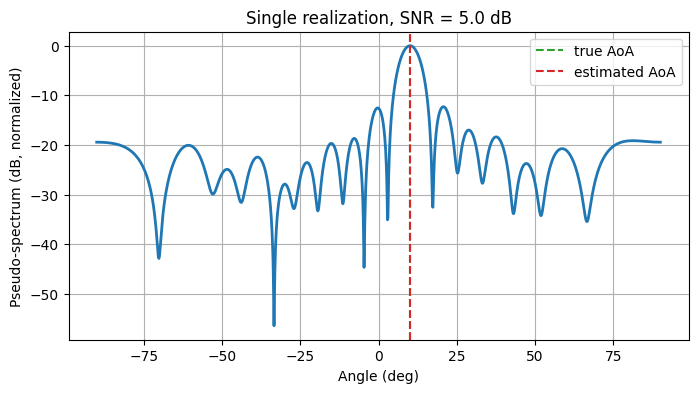

In [4]:
spectrum_db = 10.0 * np.log10(single['spectrum'] / np.max(single['spectrum']) + 1e-12)

fig, ax = plt.subplots()
ax.plot(angle_grid_deg, spectrum_db, lw=2)
ax.axvline(theta_true_deg, color='tab:green', ls='--', lw=1.5, label='true AoA')
ax.axvline(theta_hat_deg, color='tab:red', ls='--', lw=1.5, label='estimated AoA')
ax.set_xlabel('Angle (deg)')
ax.set_ylabel('Pseudo-spectrum (dB, normalized)')
ax.set_title(f'Single realization, SNR = {snr_db_single:.1f} dB')
ax.legend(loc='best')
plt.show()

Empirical Pfa on test set: 0.0027


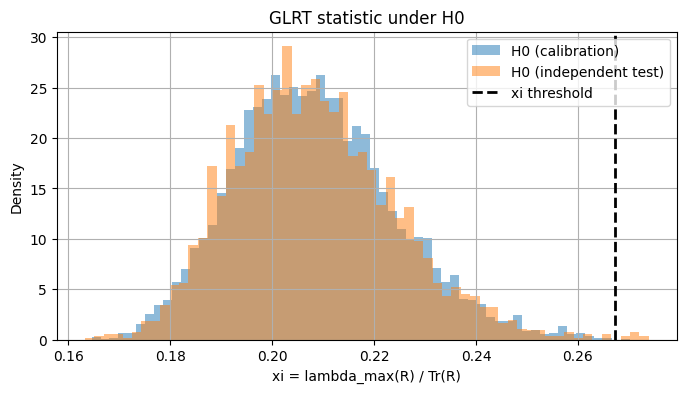

In [5]:
# Independent false-alarm check on fresh H0 data
if enable_glrt_eval:
    n_h0_test = 3000
    rng_fa = np.random.default_rng(99)
    xi_h0_test = np.empty(n_h0_test)

    for k in range(n_h0_test):
        Y0 = simulate_h0(M=M, T=T, sigma2=sigma2, rng=rng_fa)
        out0 = analyze_snapshot(Y0, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
        xi_h0_test[k] = out0['xi']

    empirical_pfa = np.mean(xi_h0_test > xi_th)
    print(f'Empirical Pfa on test set: {empirical_pfa:.4f}')

    fig, ax = plt.subplots()
    ax.hist(xi_h0_cal, bins=60, alpha=0.5, density=True, label='H0 (calibration)')
    ax.hist(xi_h0_test, bins=60, alpha=0.5, density=True, label='H0 (independent test)')
    ax.axvline(xi_th, color='k', ls='--', lw=2, label='xi threshold')
    ax.set_xlabel('xi = lambda_max(R) / Tr(R)')
    ax.set_ylabel('Density')
    ax.set_title('GLRT statistic under H0')
    ax.legend(loc='best')
    plt.show()
else:
    xi_h0_test = np.array([])
    empirical_pfa = np.nan
    print('[warning] False-alarm evaluation skipped because T=1.')


At SNR=5.0 dB, estimated Pd: 1.0000


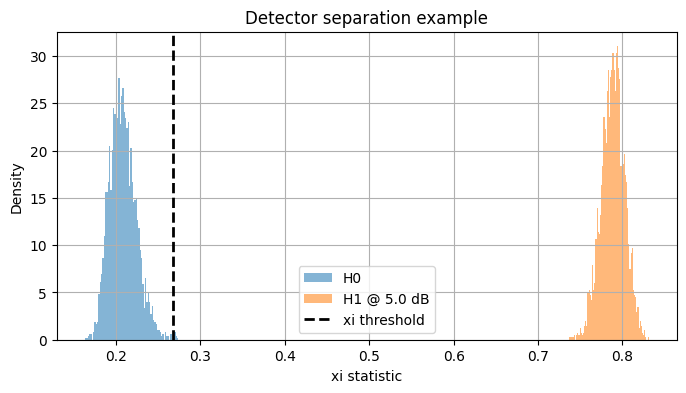

In [6]:
# Separation view: H0 vs H1 xi distributions at a selected SNR
snr_hist_db = snr_db_single
theta_hist_deg = theta_true_deg
n_hist = 3000

if enable_glrt_eval:
    rng_hist = np.random.default_rng(123)
    xi_h1_hist = np.empty(n_hist)

    for k in range(n_hist):
        Y1, _, _, _ = simulate_h1(
            theta_deg=theta_hist_deg,
            snr_db=snr_hist_db,
            M=M,
            T=T,
            sigma2=sigma2,
            qam_order=qam_order,
            d_over_lambda=d_over_lambda,
            rng=rng_hist,
        )
        out1 = analyze_snapshot(Y1, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
        xi_h1_hist[k] = out1['xi']

    pd_hist = np.mean(xi_h1_hist > xi_th)
    print(f'At SNR={snr_hist_db:.1f} dB, estimated Pd: {pd_hist:.4f}')

    fig, ax = plt.subplots()
    ax.hist(xi_h0_test, bins=70, alpha=0.55, density=True, label='H0')
    ax.hist(xi_h1_hist, bins=70, alpha=0.55, density=True, label=f'H1 @ {snr_hist_db:.1f} dB')
    ax.axvline(xi_th, color='k', ls='--', lw=2, label='xi threshold')
    ax.set_xlabel('xi statistic')
    ax.set_ylabel('Density')
    ax.set_title('Detector separation example')
    ax.legend(loc='best')
    plt.show()
else:
    xi_h1_hist = np.array([])
    pd_hist = np.nan
    print('[warning] Detector separation plot skipped because T=1.')


In [7]:
# Monte Carlo performance sweep versus SNR
snr_grid_db = np.arange(-18, 13, 3)
n_trials_per_snr = 1200
theta_true_mc = theta_true_deg
rng_mc = np.random.default_rng(2027)

pd = np.full(len(snr_grid_db), np.nan)
rmse_all = np.empty(len(snr_grid_db))
rmse_det = np.full(len(snr_grid_db), np.nan)
u_align_mean = np.empty(len(snr_grid_db))

for i, snr_db in enumerate(snr_grid_db):
    det_flags = np.zeros(n_trials_per_snr, dtype=bool)
    theta_errors = np.empty(n_trials_per_snr)
    u_align = np.empty(n_trials_per_snr)

    for n in range(n_trials_per_snr):
        Y1, u_true, _, _ = simulate_h1(
            theta_deg=theta_true_mc,
            snr_db=snr_db,
            M=M,
            T=T,
            sigma2=sigma2,
            qam_order=qam_order,
            d_over_lambda=d_over_lambda,
            rng=rng_mc,
        )

        out = analyze_snapshot(Y1, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)

        if enable_glrt_eval:
            det_flags[n] = out['xi'] > xi_th
        theta_errors[n] = out['theta_hat'] - theta_true_mc
        u_align[n] = np.abs(np.vdot(u_true, out['u_hat'])) ** 2

    if enable_glrt_eval:
        pd[i] = np.mean(det_flags)
        rmse_det[i] = np.sqrt(np.mean(theta_errors[det_flags] ** 2)) if np.any(det_flags) else np.nan

    rmse_all[i] = np.sqrt(np.mean(theta_errors ** 2))
    u_align_mean[i] = np.mean(u_align)

print('Sweep complete.')


Sweep complete.


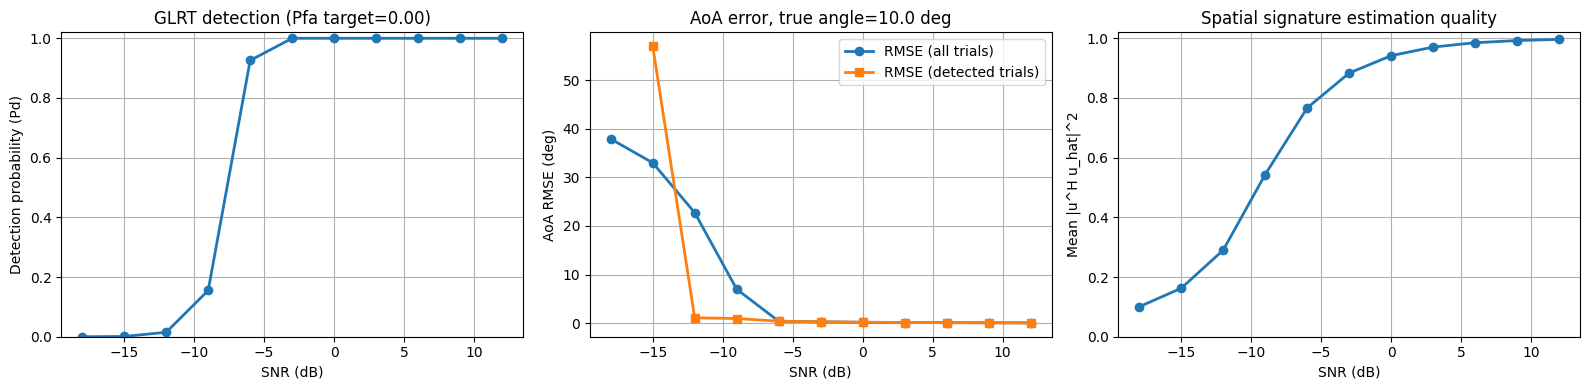

SNR(dB) |   Pd   | RMSE_all | RMSE_detected | mean|u^H u_hat|^2
  -18.0 |  0.000 |   37.907 |           nan |           0.1004
  -15.0 |  0.001 |   32.993 |        57.000 |           0.1626
  -12.0 |  0.015 |   22.739 |         1.083 |           0.2902
   -9.0 |  0.155 |    6.982 |         0.953 |           0.5435
   -6.0 |  0.926 |    0.400 |         0.394 |           0.7667
   -3.0 |  1.000 |    0.267 |         0.267 |           0.8835
    0.0 |  1.000 |    0.184 |         0.184 |           0.9417
    3.0 |  1.000 |    0.129 |         0.129 |           0.9706
    6.0 |  1.000 |    0.096 |         0.096 |           0.9852
    9.0 |  1.000 |    0.072 |         0.072 |           0.9925
   12.0 |  1.000 |    0.051 |         0.051 |           0.9963


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

if enable_glrt_eval:
    axes[0].plot(snr_grid_db, pd, marker='o', lw=2)
    axes[0].set_ylabel('Detection probability (Pd)')
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_title(f'GLRT detection (Pfa target={pfa_target:.2f})')
else:
    axes[0].text(0.5, 0.5, 'GLRT skipped for T=1\n(xi statistic is degenerate)', ha='center', va='center')
    axes[0].set_ylabel('Detection probability (Pd)')
    axes[0].set_ylim(0.0, 1.02)
    axes[0].set_title('GLRT detection not applicable')
axes[0].set_xlabel('SNR (dB)')

axes[1].plot(snr_grid_db, rmse_all, marker='o', lw=2, label='RMSE (all trials)')
if enable_glrt_eval:
    axes[1].plot(snr_grid_db, rmse_det, marker='s', lw=2, label='RMSE (detected trials)')
axes[1].set_xlabel('SNR (dB)')
axes[1].set_ylabel('AoA RMSE (deg)')
axes[1].set_title(f'AoA error, true angle={theta_true_mc:.1f} deg')
axes[1].legend(loc='best')

axes[2].plot(snr_grid_db, u_align_mean, marker='o', lw=2)
axes[2].set_xlabel('SNR (dB)')
axes[2].set_ylabel('Mean |u^H u_hat|^2')
axes[2].set_ylim(0.0, 1.02)
axes[2].set_title('Spatial signature estimation quality')

plt.tight_layout()
plt.show()

print('SNR(dB) |   Pd   | RMSE_all | RMSE_detected | mean|u^H u_hat|^2')
for s, a, b, c, d in zip(snr_grid_db, pd, rmse_all, rmse_det, u_align_mean):
    print(f'{s:7.1f} | {a:6.3f} | {b:8.3f} | {c:13.3f} | {d:16.4f}')


## Nulling and INR vs SNR

This section uses your GLRT-estimated spatial signature as $\hat{u}_1$, then forms
a nulling beam toward a known desired-user direction $u_0$. We compare:

- No nulling (use $u_0$ directly)
- Oracle nulling (use true $u_1$)
- Practical nulling (use estimated $\hat{u}_1$)

INR is evaluated as $\mathrm{INR}=\gamma|v^H u_1|^2$. The Appendix-C Eq. (57) approximation is also plotted as $\gamma_I(1-\eta)^2|\rho|^2/(1-\eta^2|\rho|^2)$.

In [9]:
def nulling_vector(u0, u_ref, eps=1e-12):
    """
    Construct v that maximizes |v^H u0|^2 subject to v^H u_ref = 0.
    Returns unit-norm v.
    """
    rho = np.vdot(u_ref, u0)
    denom = 1.0 - np.abs(rho) ** 2

    if denom <= eps:
        # Degenerate case: u0 almost parallel to u_ref.
        # Build any stable unit vector orthogonal to u_ref.
        e = np.zeros_like(u_ref)
        e[np.argmin(np.abs(u_ref))] = 1.0
        v = e - np.vdot(u_ref, e) * u_ref
        v_norm = np.linalg.norm(v)
        if v_norm <= eps:
            raise ValueError('Failed to build an orthogonal nulling vector.')
        return v / v_norm, rho

    v = (u0 - rho * u_ref) / np.sqrt(denom)
    v = v / np.linalg.norm(v)
    return v, rho


def eq57_inr(gamma_i, eta, rho, eps=1e-15):
    """Simplified delta=0 INR: gamma_i * (1-eta)^2 |rho|^2 / (1-eta |rho|^2)."""
    eta_safe = np.clip(np.real(eta), 0.0, 1.0)
    rho_abs2 = np.abs(rho) ** 2
    denom = np.maximum(1.0 - eta_safe* rho_abs2, eps)
    return gamma_i * (1.0 - eta_safe) ** 2 * rho_abs2 / denom


In [10]:
# Batched INR simulation setup
from tqdm.auto import tqdm

theta0_deg = 0.0    # desired user angle: u0 is assumed perfectly known
theta1_deg = 18.0   # true interferer angle: u1

# Change this list to sweep any antenna counts in one run, e.g. [4, 16, 32, 64].
antenna_list_inr = np.array([4, 8, 16, 32], dtype=int)

# Log-spaced SNR grid: linear gamma is equally spaced on a log scale.
snr_lin_grid_inr = np.logspace(-15.0 / 10.0, 20.0 / 10.0, 200)
snr_grid_db_inr = 10.0 * np.log10(snr_lin_grid_inr)
n_trials_inr = 1500
rng_seed_inr = 404


def db10(x, floor=1e-15):
    return 10.0 * np.log10(np.maximum(np.real(x), floor))


def eq58_einr(gamma_i, eta, rho, n_rx):
    """Appendix Eq. (58): gamma_i * [(1-eta)^2 |rho|^2 + eta (1-eta)/N_rx]."""
    eta_safe = np.clip(np.real(eta), 0.0, 1.0)
    rho_abs2_local = np.abs(rho) ** 2
    return gamma_i * ((1.0 - eta_safe) ** 2 * rho_abs2_local + eta_safe * (1.0 - eta_safe) / n_rx)


def eq58_measured_delta_einr(gamma_i, eta, rho, delta_abs2):
    """Eq. (58) expansion, but using measured E|delta|^2 before substituting (1-eta)/N_rx."""
    eta_safe = np.clip(np.real(eta), 0.0, 1.0)
    rho_abs2_local = np.abs(rho) ** 2
    return gamma_i * ((1.0 - eta_safe) ** 2 * rho_abs2_local + eta_safe * np.maximum(delta_abs2, 0.0))


def inr_upper_no_delta(gamma_i, eta):
    """No-delta deterministic upper bound: INR <= gamma_i * (1 - eta)."""
    eta_safe = np.clip(np.real(eta), 0.0, 1.0)
    return gamma_i * (1.0 - eta_safe)


def inr_isotropic_no_delta(gamma_i, eta, rho, n_tx, kappa=1.0, eps=1e-15):
    """No-delta isotropic-error model with optional variance inflation kappa.

    Uses E|delta|^2 ~= kappa * (1-eta) * (1-|rho|^2) / (n_tx-1).
    kappa=1 gives the mean isotropic model; kappa>1 gives a conservative envelope.
    """
    eta_safe = np.clip(np.real(eta), 0.0, 1.0)
    rho_abs2_local = np.abs(rho) ** 2
    q = 1.0 - eta_safe
    n_orth = max(int(n_tx) - 1, 1)
    delta_var = kappa * q * max(1.0 - rho_abs2_local, 0.0) / n_orth
    denom = np.maximum(1.0 - eta_safe * rho_abs2_local - delta_var, eps)
    return gamma_i * (q ** 2 * rho_abs2_local + eta_safe * delta_var) / denom


def isotropic_delta_kappa(n_tx, outage_prob=0.05):
    """Relative |delta|^2 inflation for a complex isotropic error direction.

    If X=|z^H a|^2/||a||^2 with z uniform in a d-dimensional complex unit sphere,
    X ~ Beta(1,d-1). This returns x_(1-outage) / E[X].
    """
    d = max(int(n_tx) - 1, 1)
    if d <= 1:
        return 1.0
    outage_safe = np.clip(outage_prob, 1e-12, 1.0 - 1e-12)
    x_quantile = 1.0 - outage_safe ** (1.0 / (d - 1))
    return d * x_quantile


def run_single_antenna_inr_sweep(m_rx, rng):
    """Run the INR/overlap sweep for one antenna count and return all plot/print data."""
    m_rx = int(m_rx)
    u0 = steering_vector(theta0_deg, m_rx, d_over_lambda)
    u1 = steering_vector(theta1_deg, m_rx, d_over_lambda)
    rho = np.vdot(u1, u0)
    rho_abs2 = np.abs(rho) ** 2
    n_grid = len(snr_grid_db_inr)

    inr_no_null_db = np.empty(n_grid)
    inr_oracle_db = np.empty(n_grid)
    inr_est_db = np.empty(n_grid)
    inr_formula_db = np.empty(n_grid)
    inr_formula_theory_eta_db = np.empty(n_grid)
    inr_formula_approx_eta_db = np.empty(n_grid)
    inr_eq57_emp_db = np.empty(n_grid)
    inr_eq57_theory_eta_db = np.empty(n_grid)
    inr_eq57_approx_eta_db = np.empty(n_grid)
    u1_align_mean = np.empty(n_grid)
    orth_err_mean = np.empty(n_grid)
    delta_abs2_mean = np.empty(n_grid)

    # Save terms needed for eta/alpha/beta validation.
    beta = T / m_rx
    tau_u_mean = np.empty(n_grid)
    tau_v_mean = np.empty(n_grid)
    tau_w_mean = np.empty(n_grid)
    alpha_mean = np.empty(n_grid)
    alpha_over_beta_mean = np.empty(n_grid)
    eta_emp_mean = np.empty(n_grid)
    eta_theory_exact_mean = np.empty(n_grid)
    eta_theory_approx_mean = np.empty(n_grid)
    eta_theory_exact_uhat_mean = np.empty(n_grid)
    eta_theory_approx_uhat_mean = np.empty(n_grid)

    for i, gamma_lin in enumerate(tqdm(snr_lin_grid_inr, desc=f'M={m_rx} SNR grid', leave=False)):
        snr_db = snr_grid_db_inr[i]

        inr_no_trials = np.empty(n_trials_inr)
        inr_oracle_trials = np.empty(n_trials_inr)
        inr_est_trials = np.empty(n_trials_inr)
        inr_formula_trials = np.empty(n_trials_inr)
        inr_formula_theory_eta_trials = np.empty(n_trials_inr)
        inr_formula_approx_eta_trials = np.empty(n_trials_inr)
        inr_eq57_emp_trials = np.empty(n_trials_inr)
        inr_eq57_theory_eta_trials = np.empty(n_trials_inr)
        inr_eq57_approx_eta_trials = np.empty(n_trials_inr)
        align_trials = np.empty(n_trials_inr)
        orth_err_trials = np.empty(n_trials_inr)
        delta_abs2_trials = np.empty(n_trials_inr)

        tau_u_trials = np.empty(n_trials_inr)
        tau_v_trials = np.empty(n_trials_inr)
        tau_w_trials = np.empty(n_trials_inr)
        alpha_trials = np.empty(n_trials_inr)
        eta_theory_trials = np.empty(n_trials_inr)
        eta_approx_trials = np.empty(n_trials_inr)
        eta_theory_uhat_trials = np.empty(n_trials_inr)
        eta_approx_uhat_trials = np.empty(n_trials_inr)

        for n in range(n_trials_inr):
            Y, u1_true, b_vec, g_true = simulate_h1(
                theta_deg=theta1_deg,
                snr_db=snr_db,
                M=m_rx,
                T=T,
                sigma2=sigma2,
                qam_order=qam_order,
                d_over_lambda=d_over_lambda,
                rng=rng,
            )

            out = analyze_snapshot(Y, angle_grid_deg=angle_grid_deg, d_over_lambda=d_over_lambda)
            u1_hat = out['u_hat']

            # v_oracle: null with perfect interferer signature u1.
            v_oracle, _ = nulling_vector(u0, u1_true)
            # v_est: null with estimated interferer signature u1hat.
            v_est, _ = nulling_vector(u0, u1_hat)

            inr_no_trials[n] = gamma_lin * np.abs(np.vdot(u0, u1_true)) ** 2
            inr_oracle_trials[n] = gamma_lin * np.abs(np.vdot(v_oracle, u1_true)) ** 2
            inr_est_trials[n] = gamma_lin * np.abs(np.vdot(v_est, u1_true)) ** 2

            phase = np.angle(np.vdot(u1_true, u1_hat))
            u1_hat_aligned = u1_hat * np.exp(-1j * phase)
            eta_emp = np.abs(np.vdot(u1_true, u1_hat_aligned)) ** 2
            eta_emp_safe = float(np.clip(eta_emp, 0.0, 1.0))
            e_vec = u1_hat_aligned - np.sqrt(eta_emp_safe) * u1_true
            delta = np.vdot(e_vec, u0)
            hat_rho = np.sqrt(eta_emp_safe) * rho + delta
            leakage_num = np.abs((1.0 - eta_emp_safe) * rho - np.sqrt(eta_emp_safe) * delta) ** 2
            leakage_den = max(1.0 - np.abs(hat_rho) ** 2, 1e-15)
            inr_formula_trials[n] = gamma_lin * leakage_num / leakage_den
            inr_eq57_emp_trials[n] = eq57_inr(gamma_lin, eta_emp_safe, rho)

            align_trials[n] = eta_emp
            orth_err_trials[n] = np.abs(np.vdot(v_est, u1_hat)) ** 2
            delta_abs2_trials[n] = np.abs(delta) ** 2

            # ---- eta/alpha/beta terms matched to the paper ----
            # We simulate b = g s with ||u||_2 = 1 and E|s|^2 = 1.
            # The code SNR is gamma_lin = |g|^2 / (M sigma2), so the large-matrix
            # sensing SNR used in the paper is gamma_lm = |g|^2 / sigma2 = M * gamma_lin.
            gamma_lm = m_rx * gamma_lin
            tau_u = gamma_lm * np.mean(np.abs(u1_true) ** 2)
            tau_v = np.mean(np.abs(b_vec / g_true) ** 2)
            tau_w = sigma2 / m_rx

            alpha = tau_w / (tau_u * tau_v)
            eta_exact = (beta - alpha ** 2) / (beta + alpha)
            eta_approx = 1.0 - alpha / beta
            eta_exact_safe = float(np.clip(eta_exact, 0.0, 1.0))
            eta_approx_safe = float(np.clip(eta_approx, 0.0, 1.0))

            tau_u_hat = gamma_lm * np.mean(np.abs(u1_hat) ** 2)
            alpha_uhat = tau_w / (tau_u_hat * tau_v)
            eta_exact_uhat = (beta - alpha_uhat ** 2) / (beta + alpha_uhat)
            eta_approx_uhat = 1.0 - alpha_uhat / beta

            leakage_num_theory_eta = np.abs((1.0 - eta_exact_safe) * rho - np.sqrt(eta_exact_safe) * delta) ** 2
            leakage_den_theory_eta = max(1.0 - np.abs(np.sqrt(eta_exact_safe) * rho + delta) ** 2, 1e-15)
            inr_formula_theory_eta_trials[n] = gamma_lin * leakage_num_theory_eta / leakage_den_theory_eta
            inr_eq57_theory_eta_trials[n] = eq57_inr(gamma_lin, eta_exact_safe, rho)

            leakage_num_approx_eta = np.abs((1.0 - eta_approx_safe) * rho - np.sqrt(eta_approx_safe) * delta) ** 2
            leakage_den_approx_eta = max(1.0 - np.abs(np.sqrt(eta_approx_safe) * rho + delta) ** 2, 1e-15)
            inr_formula_approx_eta_trials[n] = gamma_lin * leakage_num_approx_eta / leakage_den_approx_eta
            inr_eq57_approx_eta_trials[n] = eq57_inr(gamma_lin, eta_approx_safe, rho)

            tau_u_trials[n] = tau_u
            tau_v_trials[n] = tau_v
            tau_w_trials[n] = tau_w
            alpha_trials[n] = alpha
            eta_theory_trials[n] = eta_exact
            eta_approx_trials[n] = eta_approx
            eta_theory_uhat_trials[n] = eta_exact_uhat
            eta_approx_uhat_trials[n] = eta_approx_uhat

        inr_no_null_db[i] = db10(np.mean(inr_no_trials))
        inr_oracle_db[i] = db10(np.mean(inr_oracle_trials))
        inr_est_db[i] = db10(np.mean(inr_est_trials))
        inr_formula_db[i] = db10(np.mean(inr_formula_trials))
        inr_formula_theory_eta_db[i] = db10(np.mean(inr_formula_theory_eta_trials))
        inr_formula_approx_eta_db[i] = db10(np.mean(inr_formula_approx_eta_trials))
        inr_eq57_emp_db[i] = db10(np.mean(inr_eq57_emp_trials))
        inr_eq57_theory_eta_db[i] = db10(np.mean(inr_eq57_theory_eta_trials))
        inr_eq57_approx_eta_db[i] = db10(np.mean(inr_eq57_approx_eta_trials))

        u1_align_mean[i] = np.mean(align_trials)
        orth_err_mean[i] = np.mean(orth_err_trials)
        delta_abs2_mean[i] = np.mean(delta_abs2_trials)

        tau_u_mean[i] = np.mean(tau_u_trials)
        tau_v_mean[i] = np.mean(tau_v_trials)
        tau_w_mean[i] = np.mean(tau_w_trials)
        alpha_mean[i] = np.mean(alpha_trials)
        alpha_over_beta_mean[i] = np.mean(alpha_trials / beta)

        eta_emp_mean[i] = np.mean(align_trials)
        eta_theory_exact_mean[i] = np.mean(eta_theory_trials)
        eta_theory_approx_mean[i] = np.mean(eta_approx_trials)
        eta_theory_exact_uhat_mean[i] = np.mean(eta_theory_uhat_trials)
        eta_theory_approx_uhat_mean[i] = np.mean(eta_approx_uhat_trials)

    eta_err_exact = np.abs(eta_emp_mean - eta_theory_exact_mean)
    eta_err_approx = np.abs(eta_emp_mean - eta_theory_approx_mean)

    inr_formula_gap_db = np.abs(inr_est_db - inr_formula_db)
    inr_formula_theory_eta_gap_db = np.abs(inr_est_db - inr_formula_theory_eta_db)
    inr_formula_approx_eta_gap_db = np.abs(inr_est_db - inr_formula_approx_eta_db)
    inr_eq57_emp_gap_db = np.abs(inr_est_db - inr_eq57_emp_db)
    inr_eq57_theory_eta_gap_db = np.abs(inr_est_db - inr_eq57_theory_eta_db)
    inr_eq57_approx_eta_gap_db = np.abs(inr_est_db - inr_eq57_approx_eta_db)

    n_rx_eq58 = m_rx
    inr_eq58_measured_delta_db = db10(eq58_measured_delta_einr(snr_lin_grid_inr, eta_emp_mean, rho, delta_abs2_mean))
    inr_eq58_emp_db = db10(eq58_einr(snr_lin_grid_inr, eta_emp_mean, rho, n_rx_eq58))
    inr_eq58_exact_eta_db = db10(eq58_einr(snr_lin_grid_inr, eta_theory_exact_mean, rho, n_rx_eq58))
    # Backward-compatible name: this is the same exact large-matrix eta curve.
    inr_eq58_theory_eta_db = inr_eq58_exact_eta_db
    inr_eq58_approx_eta_db = db10(eq58_einr(snr_lin_grid_inr, eta_theory_approx_mean, rho, n_rx_eq58))
    inr_upper_emp_db = db10(inr_upper_no_delta(snr_lin_grid_inr, eta_emp_mean))
    inr_upper_theory_eta_db = db10(inr_upper_no_delta(snr_lin_grid_inr, eta_theory_exact_mean))
    inr_upper_approx_eta_db = db10(inr_upper_no_delta(snr_lin_grid_inr, eta_theory_approx_mean))
    kappa_iso_95 = isotropic_delta_kappa(m_rx, outage_prob=0.05)
    inr_iso_emp_db = db10(inr_isotropic_no_delta(snr_lin_grid_inr, eta_emp_mean, rho, m_rx))
    inr_iso_theory_eta_db = db10(inr_isotropic_no_delta(snr_lin_grid_inr, eta_theory_exact_mean, rho, m_rx))
    inr_iso_approx_eta_db = db10(inr_isotropic_no_delta(snr_lin_grid_inr, eta_theory_approx_mean, rho, m_rx))
    inr_iso95_theory_eta_db = db10(inr_isotropic_no_delta(snr_lin_grid_inr, eta_theory_exact_mean, rho, m_rx, kappa=kappa_iso_95))

    eta_emp_safe_eq58 = np.clip(np.real(eta_emp_mean), 0.0, 1.0)
    eq58_delta_model_abs2 = (1.0 - eta_emp_safe_eq58) / n_rx_eq58
    eq58_delta_model_gap = np.abs(delta_abs2_mean - eq58_delta_model_abs2)
    inr_eq58_measured_delta_gap_db = np.abs(inr_est_db - inr_eq58_measured_delta_db)
    inr_eq58_emp_gap_db = np.abs(inr_est_db - inr_eq58_emp_db)
    inr_eq58_exact_eta_gap_db = np.abs(inr_est_db - inr_eq58_exact_eta_db)
    # Backward-compatible name: this is the same exact large-matrix eta gap.
    inr_eq58_theory_eta_gap_db = inr_eq58_exact_eta_gap_db
    inr_eq58_approx_eta_gap_db = np.abs(inr_est_db - inr_eq58_approx_eta_db)
    inr_upper_emp_margin_db = inr_upper_emp_db - inr_est_db
    inr_upper_theory_eta_margin_db = inr_upper_theory_eta_db - inr_est_db
    inr_upper_approx_eta_margin_db = inr_upper_approx_eta_db - inr_est_db
    inr_iso_emp_gap_db = np.abs(inr_est_db - inr_iso_emp_db)
    inr_iso_theory_eta_gap_db = np.abs(inr_est_db - inr_iso_theory_eta_db)
    inr_iso_approx_eta_gap_db = np.abs(inr_est_db - inr_iso_approx_eta_db)
    inr_iso95_theory_eta_margin_db = inr_iso95_theory_eta_db - inr_est_db
    inr_upper_emp_violations = int(np.sum(inr_upper_emp_margin_db < -1e-9))
    inr_upper_theory_eta_violations = int(np.sum(inr_upper_theory_eta_margin_db < -1e-9))
    inr_upper_approx_eta_violations = int(np.sum(inr_upper_approx_eta_margin_db < -1e-9))
    inr_iso95_theory_eta_violations = int(np.sum(inr_iso95_theory_eta_margin_db < -1e-9))

    return {
        'm_rx': m_rx,
        'beta': beta,
        'rho': rho,
        'rho_abs2': rho_abs2,
        'snr_lin_grid_inr': snr_lin_grid_inr,
        'snr_grid_db_inr': snr_grid_db_inr,
        'inr_no_null_db': inr_no_null_db,
        'inr_oracle_db': inr_oracle_db,
        'inr_est_db': inr_est_db,
        'inr_formula_db': inr_formula_db,
        'inr_formula_theory_eta_db': inr_formula_theory_eta_db,
        'inr_formula_approx_eta_db': inr_formula_approx_eta_db,
        'inr_eq57_emp_db': inr_eq57_emp_db,
        'inr_eq57_theory_eta_db': inr_eq57_theory_eta_db,
        'inr_eq57_approx_eta_db': inr_eq57_approx_eta_db,
        'inr_eq58_measured_delta_db': inr_eq58_measured_delta_db,
        'inr_eq58_emp_db': inr_eq58_emp_db,
        'inr_eq58_exact_eta_db': inr_eq58_exact_eta_db,
        'inr_eq58_theory_eta_db': inr_eq58_theory_eta_db,
        'inr_eq58_approx_eta_db': inr_eq58_approx_eta_db,
        'inr_upper_emp_db': inr_upper_emp_db,
        'inr_upper_theory_eta_db': inr_upper_theory_eta_db,
        'inr_upper_approx_eta_db': inr_upper_approx_eta_db,
        'inr_iso_emp_db': inr_iso_emp_db,
        'inr_iso_theory_eta_db': inr_iso_theory_eta_db,
        'inr_iso_approx_eta_db': inr_iso_approx_eta_db,
        'inr_iso95_theory_eta_db': inr_iso95_theory_eta_db,
        'u1_align_mean': u1_align_mean,
        'orth_err_mean': orth_err_mean,
        'delta_abs2_mean': delta_abs2_mean,
        'tau_u_mean': tau_u_mean,
        'tau_v_mean': tau_v_mean,
        'tau_w_mean': tau_w_mean,
        'alpha_mean': alpha_mean,
        'alpha_over_beta_mean': alpha_over_beta_mean,
        'eta_emp_mean': eta_emp_mean,
        'eta_theory_exact_mean': eta_theory_exact_mean,
        'eta_theory_approx_mean': eta_theory_approx_mean,
        'eta_theory_exact_uhat_mean': eta_theory_exact_uhat_mean,
        'eta_theory_approx_uhat_mean': eta_theory_approx_uhat_mean,
        'eta_err_exact': eta_err_exact,
        'eta_err_approx': eta_err_approx,
        'eq58_delta_model_abs2': eq58_delta_model_abs2,
        'eq58_delta_model_gap': eq58_delta_model_gap,
        'inr_formula_gap_db': inr_formula_gap_db,
        'inr_formula_theory_eta_gap_db': inr_formula_theory_eta_gap_db,
        'inr_formula_approx_eta_gap_db': inr_formula_approx_eta_gap_db,
        'inr_eq57_emp_gap_db': inr_eq57_emp_gap_db,
        'inr_eq57_theory_eta_gap_db': inr_eq57_theory_eta_gap_db,
        'inr_eq57_approx_eta_gap_db': inr_eq57_approx_eta_gap_db,
        'inr_eq58_measured_delta_gap_db': inr_eq58_measured_delta_gap_db,
        'inr_eq58_emp_gap_db': inr_eq58_emp_gap_db,
        'inr_eq58_exact_eta_gap_db': inr_eq58_exact_eta_gap_db,
        'inr_eq58_theory_eta_gap_db': inr_eq58_theory_eta_gap_db,
        'inr_eq58_approx_eta_gap_db': inr_eq58_approx_eta_gap_db,
        'inr_upper_emp_margin_db': inr_upper_emp_margin_db,
        'inr_upper_theory_eta_margin_db': inr_upper_theory_eta_margin_db,
        'inr_upper_approx_eta_margin_db': inr_upper_approx_eta_margin_db,
        'inr_iso_emp_gap_db': inr_iso_emp_gap_db,
        'inr_iso_theory_eta_gap_db': inr_iso_theory_eta_gap_db,
        'inr_iso_approx_eta_gap_db': inr_iso_approx_eta_gap_db,
        'inr_iso95_theory_eta_margin_db': inr_iso95_theory_eta_margin_db,
        'inr_upper_emp_violations': inr_upper_emp_violations,
        'inr_upper_theory_eta_violations': inr_upper_theory_eta_violations,
        'inr_upper_approx_eta_violations': inr_upper_approx_eta_violations,
        'inr_iso95_theory_eta_violations': inr_iso95_theory_eta_violations,
        'kappa_iso_95': kappa_iso_95,
    }


inr_results_by_m = {}
for idx, m_rx in enumerate(tqdm(antenna_list_inr, desc='Antenna settings')):
    rng_m = np.random.default_rng(rng_seed_inr + 1009 * idx + int(m_rx))
    inr_results_by_m[int(m_rx)] = run_single_antenna_inr_sweep(int(m_rx), rng_m)

# Backward-compatible aliases for the antenna count used by the original single-M notebook.
primary_m_inr = int(M) if int(M) in inr_results_by_m else int(antenna_list_inr[0])
_primary_inr = inr_results_by_m[primary_m_inr]
for _name in [
    'beta', 'rho', 'rho_abs2', 'inr_no_null_db', 'inr_oracle_db', 'inr_est_db',
    'inr_formula_db', 'inr_formula_theory_eta_db', 'inr_formula_approx_eta_db',
    'inr_eq57_emp_db', 'inr_eq57_theory_eta_db', 'inr_eq57_approx_eta_db',
    'inr_eq58_measured_delta_db', 'inr_eq58_emp_db', 'inr_eq58_exact_eta_db',
    'inr_eq58_theory_eta_db', 'inr_eq58_approx_eta_db', 'inr_upper_emp_db', 'inr_upper_theory_eta_db',
    'inr_upper_approx_eta_db', 'inr_iso_emp_db', 'inr_iso_theory_eta_db',
    'inr_iso_approx_eta_db', 'inr_iso95_theory_eta_db', 'u1_align_mean',
    'orth_err_mean', 'delta_abs2_mean', 'tau_u_mean', 'tau_v_mean', 'tau_w_mean',
    'alpha_mean', 'alpha_over_beta_mean', 'eta_emp_mean', 'eta_theory_exact_mean',
    'eta_theory_approx_mean', 'eta_theory_exact_uhat_mean', 'eta_theory_approx_uhat_mean',
    'eta_err_exact', 'eta_err_approx', 'eq58_delta_model_abs2', 'eq58_delta_model_gap',
    'inr_formula_gap_db', 'inr_formula_theory_eta_gap_db', 'inr_formula_approx_eta_gap_db',
    'inr_eq57_emp_gap_db', 'inr_eq57_theory_eta_gap_db', 'inr_eq57_approx_eta_gap_db',
    'inr_eq58_measured_delta_gap_db', 'inr_eq58_emp_gap_db', 'inr_eq58_exact_eta_gap_db',
    'inr_eq58_theory_eta_gap_db', 'inr_eq58_approx_eta_gap_db', 'inr_upper_emp_margin_db', 'inr_upper_theory_eta_margin_db',
    'inr_upper_approx_eta_margin_db', 'inr_iso_emp_gap_db', 'inr_iso_theory_eta_gap_db',
    'inr_iso_approx_eta_gap_db', 'inr_iso95_theory_eta_margin_db', 'inr_upper_emp_violations',
    'inr_upper_theory_eta_violations', 'inr_upper_approx_eta_violations',
    'inr_iso95_theory_eta_violations', 'kappa_iso_95',
]:
    globals()[_name] = _primary_inr[_name]

print('Batch INR sweep complete.')
print(f'antenna_list_inr = {list(map(int, antenna_list_inr))}')
print(f'primary_m_inr aliases point to M = {primary_m_inr}')


Antenna settings:   0%|          | 0/4 [00:00<?, ?it/s]

M=4 SNR grid:   0%|          | 0/200 [00:00<?, ?it/s]

M=8 SNR grid:   0%|          | 0/200 [00:00<?, ?it/s]

M=16 SNR grid:   0%|          | 0/200 [00:00<?, ?it/s]

M=32 SNR grid:   0%|          | 0/200 [00:00<?, ?it/s]

Batch INR sweep complete.
antenna_list_inr = [4, 8, 16, 32]
primary_m_inr aliases point to M = 16


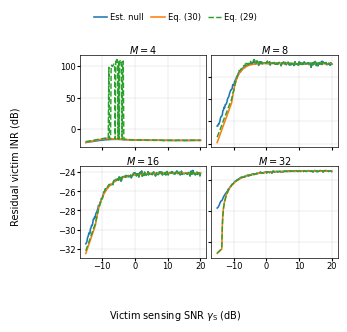

In [11]:
# IEEE single-column INR plot: one compact subplot per antenna count.
IEEE_COL_WIDTH_IN = 3.45
IEEE_DPI = 300
n_ant = len(antenna_list_inr)
n_cols = 2 if n_ant > 1 else 1
n_rows = int(np.ceil(n_ant / n_cols))
fig_height = 1.35 * n_rows + 0.55

with plt.rc_context({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'lines.linewidth': 1.1,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.35,
    'savefig.dpi': IEEE_DPI,
}):
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(IEEE_COL_WIDTH_IN, fig_height),
        squeeze=False,
        sharex=True,
    )

    handles = []
    labels = []
    for idx, (ax, m_rx) in enumerate(zip(axes.ravel(), antenna_list_inr)):
        r = inr_results_by_m[int(m_rx)]
        x = r['snr_grid_db_inr']

        line_est, = ax.plot(x, r['inr_est_db'], color='C0', lw=1.15, label='Est. null')
        line_avg, = ax.plot(x, r['inr_eq58_theory_eta_db'], color='C1', lw=1.15,
                            label='Eq. (30)')
        line_delta, = ax.plot(x, r['inr_formula_theory_eta_db'], color='C2', ls='--', lw=1.05,
                              label=r'Eq. (29)')
        if idx == 0:
            handles = [line_est, line_avg, line_delta]
            labels = [h.get_label() for h in handles]

        ax.set_title(rf'$M={int(m_rx)}$', pad=1.5)
        ax.grid(True, alpha=0.45)
        ax.tick_params(axis='both', which='major', length=2.0, pad=1.0)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    for ax in axes.ravel()[n_ant:]:
        ax.set_visible(False)

    for ax in axes[:-1, :].ravel():
        ax.tick_params(labelbottom=False)
    for ax in axes[:, 1:].ravel():
        ax.tick_params(labelleft=False)

    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=3,
        frameon=False,
        columnspacing=0.9,
        handlelength=1.6,
        handletextpad=0.35,
    )
    fig.supxlabel(r'Victim sensing SNR $\gamma_{\mathrm{S}}$ (dB)', fontsize=7, y=0.02)
    fig.supylabel('Residual victim INR (dB)', fontsize=7, x=0.02)
    fig.tight_layout(rect=(0.07, 0.07, 1.0, 0.91), h_pad=0.45, w_pad=0.25)
    plt.show()
    # fig.savefig('inr_ieee_single_column.pdf', bbox_inches='tight', pad_inches=0.01)


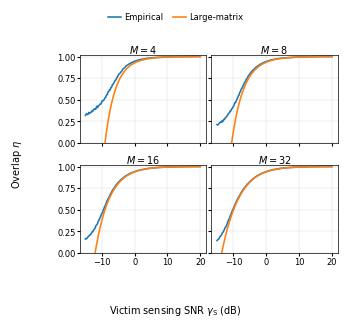


=== M = 4 ===
beta = T/M = 4.000000
alpha/beta range: [6.250e-04, 1.976e+00]
mean |eta_emp - eta_theory| = 4.205e-01
|rho|^2 = 0.249413
mean E[|delta|^2] = 4.173e-02
mean Eq. (30) (1-eta)/N_tx = 4.160e-02
mean |E[|delta|^2] - (1-eta)/N_tx| = 5.574e-04
mean |INR_est(dB) - Eq. (29) retained-delta theory-eta(dB)| = 11.948 dB
mean |INR_est(dB) - Eq. (30) average theory-eta(dB)| = 0.361 dB

=== M = 8 ===
beta = T/M = 2.000000
alpha/beta range: [6.250e-04, 1.976e+00]
mean |eta_emp - eta_theory| = 1.822e-01
|rho|^2 = 0.032752
mean E[|delta|^2] = 2.486e-02
mean Eq. (30) (1-eta)/N_tx = 2.242e-02
mean |E[|delta|^2] - (1-eta)/N_tx| = 2.443e-03
mean |INR_est(dB) - Eq. (29) retained-delta theory-eta(dB)| = 0.194 dB
mean |INR_est(dB) - Eq. (30) average theory-eta(dB)| = 0.319 dB

=== M = 16 ===
beta = T/M = 1.000000
alpha/beta range: [6.250e-04, 1.976e+00]
mean |eta_emp - eta_theory| = 7.267e-02
|rho|^2 = 0.017808
mean E[|delta|^2] = 1.157e-02
mean Eq. (30) (1-eta)/N_tx = 1.102e-02
mean |E[|delta|^

In [12]:
# IEEE single-column overlap plot and compact summary printout.
IEEE_COL_WIDTH_IN = 3.45
IEEE_DPI = 300
n_ant = len(antenna_list_inr)
n_cols = 2 if n_ant > 1 else 1
n_rows = int(np.ceil(n_ant / n_cols))
fig_height = 1.35 * n_rows + 0.50

with plt.rc_context({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'lines.linewidth': 1.1,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.35,
    'savefig.dpi': IEEE_DPI,
}):
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(IEEE_COL_WIDTH_IN, fig_height),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    handles = []
    labels = []
    for idx, (ax, m_rx) in enumerate(zip(axes.ravel(), antenna_list_inr)):
        r = inr_results_by_m[int(m_rx)]
        x = r['snr_grid_db_inr']

        line_emp, = ax.plot(x, r['eta_emp_mean'], color='C0', lw=1.15, label='Empirical')
        line_lm, = ax.plot(x, r['eta_theory_exact_mean'], color='C1', lw=1.15, label='Large-matrix')
        if idx == 0:
            handles = [line_emp, line_lm]
            labels = [h.get_label() for h in handles]

        ax.set_title(rf'$M={int(m_rx)}$', pad=1.5)
        ax.set_ylim(0.0, 1.02)
        ax.grid(True, alpha=0.45)
        ax.tick_params(axis='both', which='major', length=2.0, pad=1.0)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    for ax in axes.ravel()[n_ant:]:
        ax.set_visible(False)

    for ax in axes[:-1, :].ravel():
        ax.tick_params(labelbottom=False)
    for ax in axes[:, 1:].ravel():
        ax.tick_params(labelleft=False)

    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=2,
        frameon=False,
        columnspacing=1.2,
        handlelength=1.6,
        handletextpad=0.35,
    )
    fig.supxlabel(r'Victim sensing SNR $\gamma_{\mathrm{S}}$ (dB)', fontsize=7, y=0.02)
    fig.supylabel(r'Overlap $\eta$', fontsize=7, x=0.02)
    fig.tight_layout(rect=(0.07, 0.07, 1.0, 0.91), h_pad=0.45, w_pad=0.25)
    plt.show()
    # fig.savefig('overlap_ieee_single_column.pdf', bbox_inches='tight', pad_inches=0.01)

for m_rx in antenna_list_inr:
    r = inr_results_by_m[int(m_rx)]
    print(f'\n=== M = {int(m_rx)} ===')
    print(f'beta = T/M = {r["beta"]:.6f}')
    print(f'alpha/beta range: [{np.min(r["alpha_over_beta_mean"]):.3e}, {np.max(r["alpha_over_beta_mean"]):.3e}]')
    print(f'mean |eta_emp - eta_theory| = {np.mean(r["eta_err_exact"]):.3e}')
    print(f'|rho|^2 = {r["rho_abs2"]:.6f}')
    print(f'mean E[|delta|^2] = {np.mean(r["delta_abs2_mean"]):.3e}')
    print(f'mean Eq. (30) (1-eta)/N_tx = {np.mean(r["eq58_delta_model_abs2"]):.3e}')
    print(f'mean |E[|delta|^2] - (1-eta)/N_tx| = {np.mean(r["eq58_delta_model_gap"]):.3e}')
    print(f'mean |INR_est(dB) - Eq. (29) retained-delta theory-eta(dB)| = {np.mean(r["inr_formula_theory_eta_gap_db"]):.3f} dB')
    print(f'mean |INR_est(dB) - Eq. (30) average theory-eta(dB)| = {np.mean(r["inr_eq58_theory_eta_gap_db"]):.3f} dB')


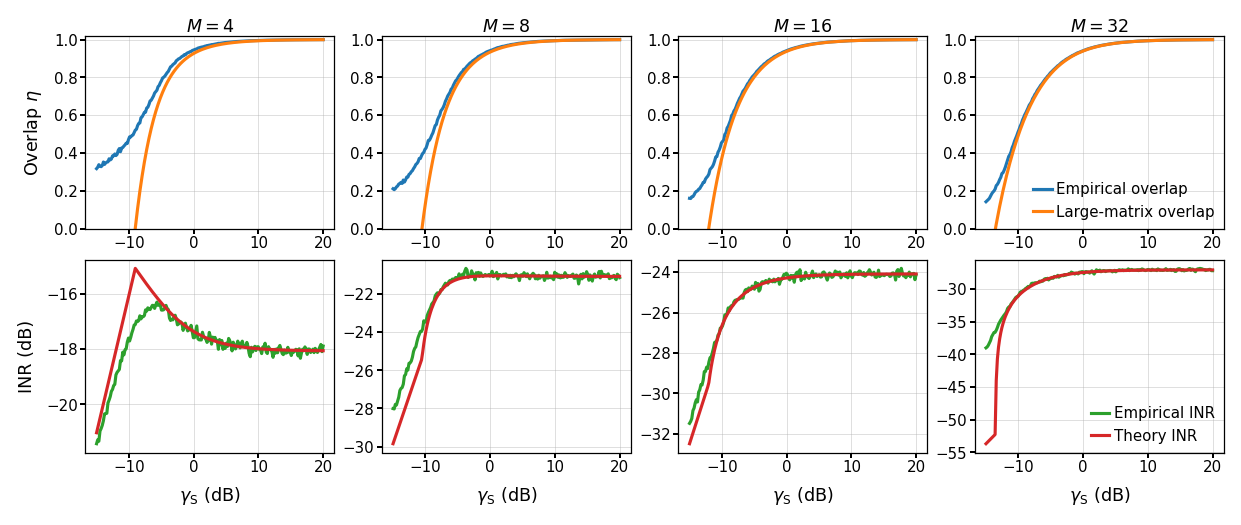

Saved figure to: /home/sj4025/my_project/NTN-NULLING-NONCOH/result/overlap_inr_ieee_double_column.png
Saved figure to: /home/sj4025/my_project/NTN-NULLING-NONCOH/result/overlap_inr_ieee_double_column.pdf


In [26]:
# IEEE double-column combined plot: first row overlap, second row INR.
# Designed for a two-column IEEE figure* width. No shared axes/ticks are used.
from pathlib import Path

IEEE_TEXT_WIDTH_IN = 7.16
IEEE_SAVE_DPI = 600
IEEE_DISPLAY_DPI = 180
RESULT_DIR = Path('/home/sj4025/my_project/NTN-NULLING-NONCOH/result')
RESULT_DIR.mkdir(parents=True, exist_ok=True)

preferred_m_list = [4, 8, 16, 32]
# Keep this list explicit so M=8 is not silently skipped.
ieee_double_m_list = preferred_m_list
fig_cols = len(ieee_double_m_list)

# Use different color families for the two rows.
overlap_colors = {
    'empirical': '#1f77b4',      # blue
    'large_matrix': '#ff7f0e',   # orange
}
inr_colors = {
    'estimated': '#2ca02c',      # green
    'eq30': '#d62728',           # red
}

with plt.rc_context({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'lines.linewidth': 1.25,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.35,
    'figure.dpi': IEEE_DISPLAY_DPI,
    'savefig.dpi': IEEE_SAVE_DPI,
}):
    fig, axes = plt.subplots(
        2,
        fig_cols,
        figsize=(IEEE_TEXT_WIDTH_IN, 3.05),
        squeeze=False,
        sharex=False,
        sharey=False,
    )

    for col, m_rx in enumerate(ieee_double_m_list):
        ax_eta = axes[0, col]
        ax_inr = axes[1, col]

        if int(m_rx) not in inr_results_by_m:
            ax_eta.set_visible(False)
            ax_inr.set_visible(False)
            print(f'[warning] M={int(m_rx)} not found in inr_results_by_m; column hidden.')
            continue

        r = inr_results_by_m[int(m_rx)]
        x = r['snr_grid_db_inr']

        # Row 1: overlap. Only the two legend curves are plotted.
        line_eta_emp, = ax_eta.plot(
            x, r['eta_emp_mean'],
            color=overlap_colors['empirical'], lw=1.25,
            label='Empirical overlap',
        )
        line_eta_lm, = ax_eta.plot(
            x, r['eta_theory_exact_mean'],
            color=overlap_colors['large_matrix'], lw=1.25,
            label='Large-matrix overlap',
        )
        ax_eta.set_title(rf'$M={int(m_rx)}$', pad=1.5)
        ax_eta.set_ylim(0.0, 1.02)
        ax_eta.grid(True, alpha=0.45)

        # Row 2: INR. Only the two legend curves are plotted.
        line_inr_est, = ax_inr.plot(
            x, r['inr_est_db'],
            color=inr_colors['estimated'], lw=1.25,
            label='Empirical INR',
        )
        line_inr_avg, = ax_inr.plot(
            x, r['inr_eq58_theory_eta_db'],
            color=inr_colors['eq30'], lw=1.25,
            label='Theory INR',
        )
        ax_inr.grid(True, alpha=0.45)
        ax_inr.set_xlabel(r'$\gamma_{\mathrm{S}}$ (dB)')

        if col == 0:
            ax_eta.set_ylabel(r'Overlap $\eta$')
            ax_inr.set_ylabel('INR (dB)')

        if col == fig_cols - 1:
            ax_eta.legend(
                handles=[line_eta_emp, line_eta_lm],
                loc='lower right',
                frameon=False,
                handlelength=1.25,
                handletextpad=0.3,
                borderaxespad=0.2,
            )
            ax_inr.legend(
                handles=[line_inr_est, line_inr_avg],
                loc='lower right',
                frameon=False,
                handlelength=1.25,
                handletextpad=0.3,
                borderaxespad=0.2,
            )

        for ax in (ax_eta, ax_inr):
            ax.tick_params(axis='both', which='major', length=2.0, pad=1.0)
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)

    fig.tight_layout(rect=(0.035, 0.02, 1.0, 0.98), h_pad=0.48, w_pad=0.45)

    png_path = RESULT_DIR / 'overlap_inr_ieee_double_column.png'
    pdf_path = RESULT_DIR / 'overlap_inr_ieee_double_column.pdf'
    fig.savefig(png_path, bbox_inches='tight', pad_inches=0.01, dpi=IEEE_SAVE_DPI)
    fig.savefig(pdf_path, bbox_inches='tight', pad_inches=0.01)
    plt.show()

print(f'Saved figure to: {png_path}')
print(f'Saved figure to: {pdf_path}')
